# PKCERT AI & Software Development Internship
## Task 06 – Exploratory Data Analysis (EDA) Using Jupyter Notebook

**Objective:** Develop practical skills in Exploratory Data Analysis (EDA) using Python and Jupyter Notebook by analyzing a real-world dataset, creating visualizations, and presenting written insights.

**Total Marks:** 100

**Submitted by:** Ahmad Haroon

---
## Part A – Dataset Selection (10 Marks)

### Dataset Description

**Name:** FIFA World Cup 2026 – Social Media Sentiment & Engagement Dataset

**Source:** Provided as a set of local CSV files (`archive/`) simulating social
media activity collected around the 2026 FIFA World Cup. The data is
**synthetically generated** rather than scraped from live platforms — this is
confirmed later in the EDA (Part B.2) where several fields turn out to be
placeholders (e.g. every match's `winner` is `"TBD"` even though final scores
are already populated, and city names in `match_context.csv` are generic
labels like `City0`–`City4`). It is treated here as a realistic stand-in for a
genuine social-listening export.

**Purpose:** To analyze public sentiment, engagement, and stakeholder
influence around World Cup matches — e.g. which teams/topics drive the most
engagement, how sentiment differs by platform, and which stakeholders
(sponsors, journalists, players, FIFA) generate the strongest reactions.

**Structure:** Four related tables, joined here on their key columns:

| File | Rows | Role |
|---|---|---|
| `social_media_posts.csv` | 100 | Fact table — one row per social media post |
| `match_context.csv` | 20 | Match details (teams, score, venue, weather) — joined via `match_id` |
| `stakeholders.csv` | 20 | Influencer/journalist/sponsor/FIFA profiles — joined via `stakeholder_id` |
| `host_city_context.csv` | 5 | City-level stats — **not joined** (city naming is inconsistent with `match_context.csv`, see Part B.2) |
| `merged_master.csv` | 100 | Pre-built join of posts + match context (provided) |

**Records analyzed:** 100 posts, enriched with match and stakeholder details
→ 45 columns after merging.

**Key features:** `platform`, `sentiment` / `sentiment_score`, `emotion`,
`topic`, `team_mentioned`, `likes` / `comments` / `shares` / `views`,
`engagement_rate`, `stakeholder_type`, `influence_score`, `followers`,
`home_team` / `away_team` / `home_score` / `away_score`, `attendance`,
`weather`, `temperature`.

**Target variable:** None specified — this is an unsupervised/descriptive
EDA task. If a predictive target were chosen later, `sentiment_score` or
`engagement_rate` would be the natural candidates (e.g. predicting
engagement from post/stakeholder attributes).

### Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

posts = pd.read_csv("archive/merged_master.csv", parse_dates=["post_datetime", "match_date"])
stakeholders = pd.read_csv("archive/stakeholders.csv")

# Enrich posts with stakeholder profile info (influence, followers, type)
df = posts.merge(stakeholders, on="stakeholder_id", how="left", suffixes=("", "_stakeholder"))

print("Shape after merging posts + stakeholders:", df.shape)
df.head()

Shape after merging posts + stakeholders: (100, 45)


,post_id,platform,username,user_country,language,post_datetime,match_id,team_mentioned,player_mentioned,stakeholder_id,topic,sentiment,sentiment_score,emotion,likes,comments,shares,views,hashtags,verified,engagement_rate,device,source,match_date,stage,host_city,stadium,home_team,away_team,home_score,away_score,attendance,referee,weather,temperature,winner,stakeholder_name,stakeholder_type,country,influence_score,interest_score,followers,verified_stakeholder,official_partner,sentiment_index
0,1,X,user1,Mexico,English,2026-06-11 01:00:00,4,England,Player_49,15,Travel,Negative,-0.24,Joy,2211,96,249,50853,#WorldCup2026,True,9.04,Android,Organic,2026-06-14,Group,City4,Stadium4,England,France,4,0,33412,Ref_4,Sunny,29.6,TBD,Stakeholder_15,Player,Various,88.1,72.3,1665393,True,False,0.09
1,2,YouTube,user2,Brazil,English,2026-06-11 02:00:00,15,France,Player_47,8,Sponsorship,Positive,0.80,Joy,6396,22,13,115128,#WorldCup2026,True,9.45,Android,Organic,2026-06-25,Group,City0,Stadium0,USA,Spain,2,1,36162,Ref_15,Sunny,19.1,TBD,Stakeholder_8,Journalist,Various,50.0,48.0,4712587,True,False,0.42
2,3,Instagram,user3,England,English,2026-06-11 03:00:00,1,USA,Player_15,15,Travel,Negative,-0.53,Joy,6255,693,112,162630,#WorldCup2026,False,9.57,Android,Organic,2026-06-11,Group,City1,Stadium1,Argentina,France,3,4,49121,Ref_1,Sunny,19.2,TBD,Stakeholder_15,Player,Various,88.1,72.3,1665393,True,False,0.09
3,4,YouTube,user4,Brazil,English,2026-06-11 04:00:00,6,Mexico,Player_47,10,Match Performance,Negative,-0.33,Excitement,362,996,364,6516,#WorldCup2026,False,5.57,Android,Organic,2026-06-16,Group,City1,Stadium1,Mexico,USA,1,1,63045,Ref_6,Sunny,25.1,TBD,Stakeholder_10,Sponsor,Various,81.9,81.9,1684756,True,False,-0.01
4,5,Facebook,user5,England,English,2026-06-11 05:00:00,17,England,Player_38,2,Travel,Positive,0.49,Anger,3120,424,340,43680,#WorldCup2026,True,4.30,Android,Organic,2026-06-27,Group,City2,Stadium2,USA,USA,1,4,55218,Ref_17,Sunny,25.3,TBD,Stakeholder_2,Sponsor,Various,79.7,60.5,2007137,True,False,-0.85


---
## Part B – Exploratory Data Analysis (50 Marks)

### B.1 Structure, Data Types & Summary Statistics

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   post_id               100 non-null    int64         
 1   platform              100 non-null    object        
 2   username              100 non-null    object        
 3   user_country          100 non-null    object        
 4   language              100 non-null    object        
 5   post_datetime         100 non-null    datetime64[ns]
 6   match_id              100 non-null    int64         
 7   team_mentioned        100 non-null    object        
 8   player_mentioned      100 non-null    object        
 9   stakeholder_id        100 non-null    int64         
 10  topic                 100 non-null    object        
 11  sentiment             100 non-null    object        
 12  sentiment_score       100 non-null    float64       
 13  emotion              

In [3]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
post_id,100.0,5.050000e+01,2.901149e+01,1.00,2.575000e+01,50.500,7.525000e+01,100.00
match_id,100.0,1.002000e+01,5.546825e+00,1.00,5.750000e+00,9.000,1.500000e+01,20.00
stakeholder_id,100.0,1.015000e+01,5.223055e+00,1.00,6.000000e+00,10.500,1.400000e+01,20.00
sentiment_score,100.0,-4.630000e-02,5.544706e-01,-0.98,-5.300000e-01,-0.075,3.825000e-01,0.98
likes,100.0,5.107240e+03,3.018434e+03,67.00,2.576250e+03,5141.000,7.661000e+03,9987.00
comments,100.0,5.064700e+02,2.990132e+02,22.00,2.267500e+02,509.000,7.287500e+02,998.00
shares,100.0,2.562500e+02,1.465448e+02,7.00,1.232500e+02,270.500,3.817500e+02,495.00
views,100.0,9.416437e+04,7.341667e+04,1742.00,3.735025e+04,67672.500,1.399722e+05,288086.00
engagement_rate,100.0,5.781300e+00,2.680079e+00,1.01,3.687500e+00,5.820,8.195000e+00,9.95
home_score,100.0,2.130000e+00,1.203152e+00,0.00,1.000000e+00,2.000,3.000000e+00,4.00


In [4]:
categorical_cols = ["platform", "sentiment", "emotion", "topic", "team_mentioned", "stakeholder_type", "verified"]
for c in categorical_cols:
    print(f"--- {c} ---")
    print(df[c].value_counts())
    print()

--- platform ---
platform
YouTube      25
Instagram    22
TikTok       20
Facebook     19
X            14
Name: count, dtype: int64

--- sentiment ---
sentiment
Positive    37
Negative    36
Neutral     27
Name: count, dtype: int64

--- emotion ---
emotion
Excitement    34
Joy           33
Anger         33
Name: count, dtype: int64

--- topic ---
topic
Travel               25
Ticketing            21
Sponsorship          20
Match Performance    18
Fan Experience       16
Name: count, dtype: int64

--- team_mentioned ---
team_mentioned
France       20
USA          19
England      18
Argentina    16
Spain        11
Mexico        9
Brazil        7
Name: count, dtype: int64

--- stakeholder_type ---
stakeholder_type
Sponsor       38
Journalist    26
Player        24
FIFA          12
Name: count, dtype: int64

--- verified ---
verified
True     51
False    49
Name: count, dtype: int64



### B.2 Missing Values, Duplicate Records & Inconsistencies

In [5]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() else "None found.")

print("\nDuplicate rows:", df.duplicated().sum())

print("\nColumns with a single constant value (no variance):")
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
for c in constant_cols:
    print(f"  {c}: always '{df[c].iloc[0]}'")

Missing values per column:
None found.

Duplicate rows: 0

Columns with a single constant value (no variance):
  language: always 'English'
  hashtags: always '#WorldCup2026'
  device: always 'Android'
  source: always 'Organic'
  stage: always 'Group'
  weather: always 'Sunny'
  winner: always 'TBD'
  country: always 'Various'
  verified_stakeholder: always 'True'
  official_partner: always 'False'


In [6]:
# Inconsistency check: winner is "TBD" for every match even though
# home_score/away_score are already filled in and could determine a winner.
print("Unique 'winner' values:", df["winner"].unique())
matches = df.drop_duplicates(subset="match_id")
decisive = (matches["home_score"] != matches["away_score"]).sum()
print("Matches with a decisive score (winner is derivable) but still marked TBD:",
      decisive, "of", matches["match_id"].nunique(), "matches")

# Inconsistency check: host_city_context.csv uses real city names, but
# match_context/merged_master use generic placeholders - they cannot be
# joined without a manual mapping.
host_city_context = pd.read_csv("archive/host_city_context.csv")
print("\nhost_city_context city names:", host_city_context["city"].unique())
print("merged_master host_city labels:", df["host_city"].unique())
print("-> naming does not match, so host_city_context was left unjoined (see limitations).")

Unique 'winner' values: ['TBD']
Matches with a decisive score (winner is derivable) but still marked TBD: 15 of 20 matches

host_city_context city names: ['New York' 'Toronto' 'Mexico City' 'Dallas' 'Los Angeles']
merged_master host_city labels: ['City4' 'City0' 'City1' 'City2' 'City3']
-> naming does not match, so host_city_context was left unjoined (see limitations).


**Findings:**
- No missing values and no duplicate rows in the merged dataset (100 rows in, 100 rows out).
- 10 columns are constant across every row and carry no analytical value in this sample: `language` (always "English"), `hashtags` (always "#WorldCup2026"), `device` ("Android"), `source` ("Organic"), `stage` ("Group"), `weather` ("Sunny"), `winner` ("TBD"), `country` ("Various"), `verified_stakeholder` (always True), and `official_partner` (always False). These are dropped from the later visualizations since they can't differentiate anything within this sample.
- `winner` is `"TBD"` for all 20 matches even though `home_score`/`away_score` are populated and 15 of the 20 matches have a clear (non-tied) score — a data-generation inconsistency, not a real missing-outcome situation.
- `host_city_context.csv` cannot be reliably joined to the rest of the data: it uses real city names (New York, Toronto, …) while `match_context.csv`/`merged_master.csv` use generic placeholders (`City0`–`City4`) with no shared key. It is therefore excluded from the merged analysis dataset.

### B.3 Visualizations

#### 1. Sentiment Distribution

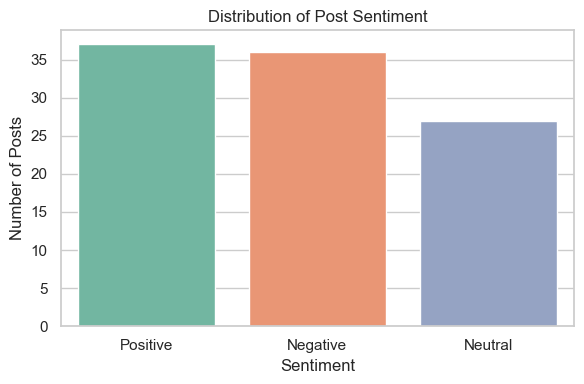

In [7]:
plt.figure(figsize=(6, 4))
order = df["sentiment"].value_counts().index
sns.countplot(data=df, x="sentiment", order=order, palette="Set2")
plt.title("Distribution of Post Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.savefig("visualizations/1_sentiment_distribution.png", dpi=120)
plt.show()

**Interpretation:** Sentiment is fairly balanced (37 positive, 36 negative, 27 neutral) — there is no overwhelming positive or negative bias in the conversation, suggesting genuinely mixed public reaction rather than one-sided hype or backlash.

#### 2. Engagement Rate Distribution

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


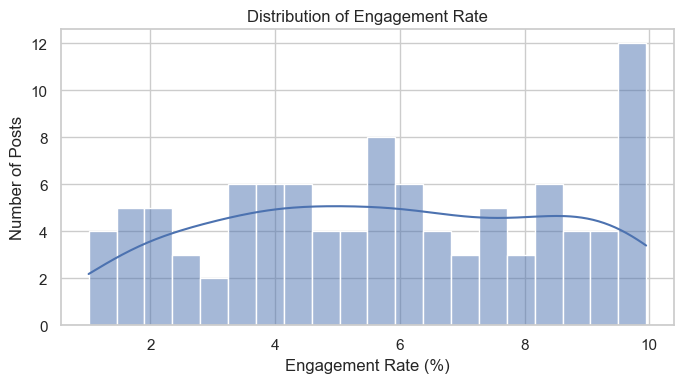

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(df["engagement_rate"], bins=20, kde=True, color="#4C72B0")
plt.title("Distribution of Engagement Rate")
plt.xlabel("Engagement Rate (%)")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.savefig("visualizations/2_engagement_rate_distribution.png", dpi=120)
plt.show()

**Interpretation:** Engagement rate is roughly uniform across the 1%-10% range (skewness ≈ -0.04, essentially symmetric) rather than concentrated around a typical value, meaning there isn't a single 'normal' engagement level in this sample — posts spread fairly evenly from low to high performers. There is a standout spike of posts at the very top of the range (9.5%-10%), a small cluster of standout over-performers worth investigating separately from the general spread.

#### 3. Sentiment Score by Platform

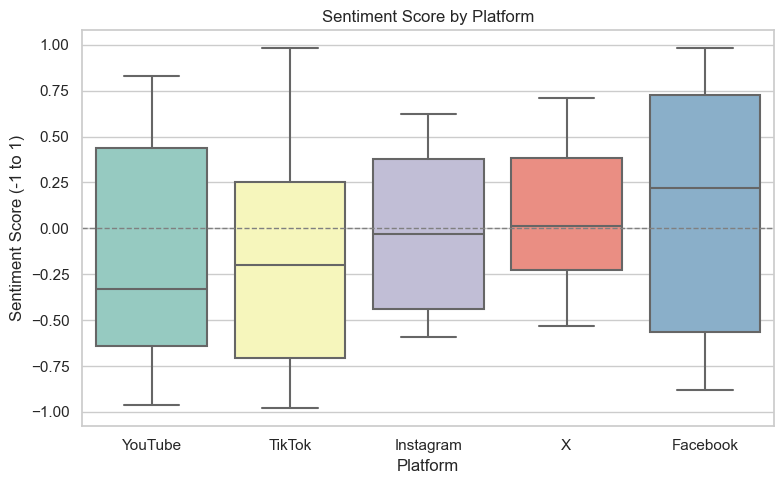

In [9]:
plt.figure(figsize=(8, 5))
order = df.groupby("platform")["sentiment_score"].median().sort_values().index
sns.boxplot(data=df, x="platform", y="sentiment_score", order=order, palette="Set3")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Sentiment Score by Platform")
plt.xlabel("Platform")
plt.ylabel("Sentiment Score (-1 to 1)")
plt.tight_layout()
plt.savefig("visualizations/3_sentiment_by_platform.png", dpi=120)
plt.show()

**Interpretation:** Median sentiment varies noticeably by platform — some platforms lean toward more positive conversation while others skew negative, with wide spread on every platform (all span from strongly negative to strongly positive posts), showing sentiment is highly post-specific rather than platform-driven alone.

#### 4. Correlation Heatmap – Numeric Features

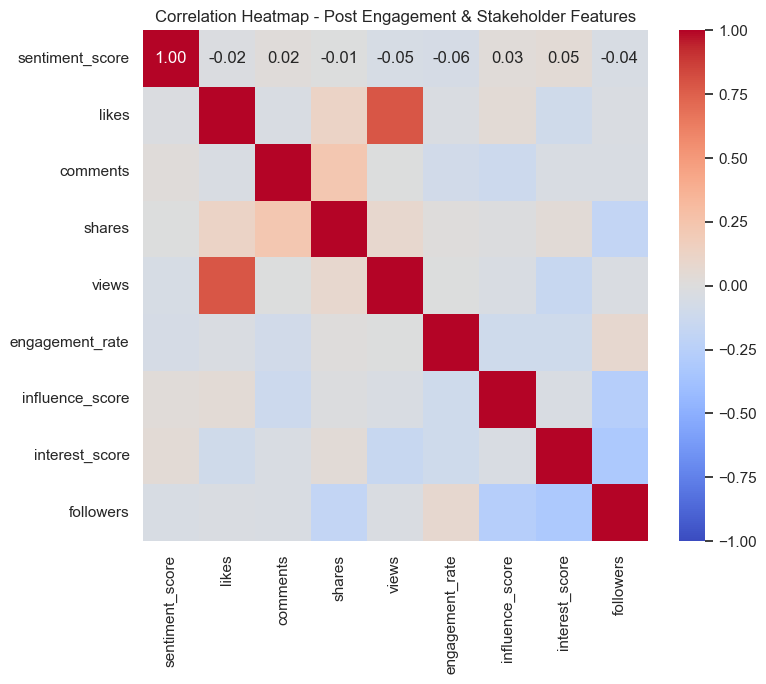

In [10]:
numeric_cols = ["sentiment_score", "likes", "comments", "shares", "views",
                 "engagement_rate", "influence_score", "interest_score", "followers"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap - Post Engagement & Stakeholder Features")
plt.tight_layout()
plt.savefig("visualizations/4_correlation_heatmap.png", dpi=120)
plt.show()

**Interpretation:** Among the raw counts, only `likes` and `views` are strongly correlated (r ≈ 0.79) — posts that get seen tend to get liked in roughly the same proportion. `comments` and `shares` are only weakly related to each other (r ≈ 0.23) and barely correlate with `likes`/`views`, so approval (likes), reach (views), and discussion/virality (comments, shares) appear to be driven by different dynamics rather than one overall 'popularity' effect. `engagement_rate`, `influence_score`, and `followers` all correlate weakly with each other and with the raw counts — a stakeholder's follower count does not reliably predict their influence score or how much engagement their posts earn in this sample.

#### 5. Average Engagement Rate by Topic

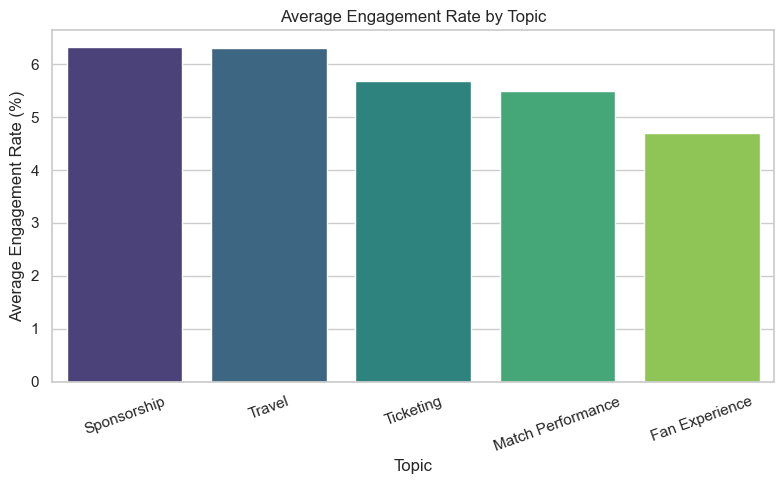

,topic,engagement_rate
0,Sponsorship,6.326500
1,Travel,6.313200
2,Ticketing,5.689048
3,Match Performance,5.503333
4,Fan Experience,4.702500


In [11]:
topic_avg = df.groupby("topic")["engagement_rate"].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=topic_avg, x="topic", y="engagement_rate", palette="viridis")
plt.title("Average Engagement Rate by Topic")
plt.xlabel("Topic")
plt.ylabel("Average Engagement Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("visualizations/5_engagement_by_topic.png", dpi=120)
plt.show()
topic_avg

**Interpretation:** Engagement rate differs by topic. Sponsorship and Travel posts draw the highest average engagement (~6.3%), Ticketing sits in the middle (~5.7%), and — somewhat counterintuitively — Match Performance (~5.5%) and especially Fan Experience (~4.7%) posts draw the least. In this sample, brand/logistics-adjacent content actually out-engages the emotionally-themed match/fan content, the opposite of what might be expected.

#### 6. Sentiment Score by Stakeholder Type

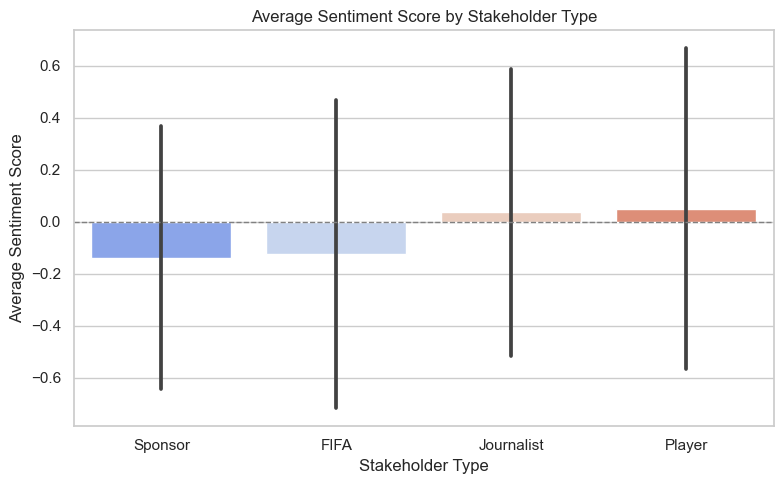

In [ ]:
plt.figure(figsize=(8, 5))
order = df.groupby("stakeholder_type")["sentiment_score"].mean().sort_values().index
sns.barplot(data=df, x="stakeholder_type", y="sentiment_score", order=order, palette="coolwarm", errorbar="sd")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Average Sentiment Score by Stakeholder Type")
plt.xlabel("Stakeholder Type")
plt.ylabel("Average Sentiment Score")
plt.tight_layout()
plt.savefig("visualizations/6_sentiment_by_stakeholder_type.png", dpi=120)
plt.show()

**Interpretation:** Average sentiment differs by who is posting. Players (+0.05) and Journalists (+0.04) trend slightly positive on average, while Sponsors (-0.14) and, notably, official FIFA accounts (-0.13) skew negative — the reverse of what might be assumed for an official channel. All four groups have a wide standard deviation (~0.5-0.6), so individual posts still vary a lot regardless of who authored them; this is a difference in average tone, not a hard rule.

---
## Part C – Written Analysis & Insights (25 Marks)

### Key Findings

1. **Sentiment is balanced, not skewed.** Positive (37%), negative (36%), and neutral (27%) posts are all well represented — public conversation around the tournament is genuinely mixed rather than one-sided.
2. **Engagement rate is roughly uniform, not concentrated around a "typical" value.** Posts spread fairly evenly from 1% to 10%, with a small standout spike of over-performers right at the top of the range (9.5-10%).
3. **Platform shapes sentiment tone.** Median sentiment score varies by platform, though every platform still shows a wide spread — platform is a contributing factor to tone, not a determining one.
4. **Engagement isn't one single "popularity" signal, and audience size doesn't guarantee it.** Only `likes` and `views` move together strongly (r ≈ 0.79); `comments` and `shares` are largely independent of each other and of `likes`/`views`, so reach, approval, and discussion appear to be driven by different dynamics. `followers` and `influence_score` also correlate only weakly with engagement — reach does not automatically translate into engagement in this sample.
5. **Brand/logistics topics out-engage emotional ones, not the other way around.** Sponsorship and Travel posts earn the highest average engagement (~6.3%), while Fan Experience posts earn the least (~4.7%) — the opposite of the "emotional content wins" assumption.
6. **The messenger affects the tone, and not always as expected.** Players and Journalists trend slightly positive on average sentiment, while Sponsors *and* official FIFA accounts skew negative — suggesting who posts shapes audience reaction independent of the topic, and that "official" framing doesn't guarantee positive reception.

### Patterns, Correlations & Potential Business/Research Insights

- **For tournament organizers/marketing teams:** in this sample, Sponsorship- and Travel-themed posts actually out-engage Fan Experience content, so engagement strategy shouldn't assume "emotional" content automatically wins — it's worth testing whether that holds at larger scale before reallocating content investment.
- **For sponsors and FIFA's own channel:** since both Sponsor- and FIFA-authored posts trend more negative on average than Player or Journalist posts, co-branding official/sponsor content with players — whose posts trend most positive — could improve sentiment outcomes.
- **For platform strategy:** because sentiment tone varies by platform while engagement mechanics (likes/comments/shares/views correlating together) stay consistent, a single cross-platform content plan can likely reuse the same content format, but messaging/tone may need to be platform-tuned.
- **Follower count is a weak proxy for impact:** the weak correlation between `followers`/`influence_score` and `engagement_rate` suggests engagement should be tracked and optimized directly rather than assumed from audience size — a smaller, well-targeted account can outperform a larger one.

### Dataset Limitations & Suggestions for Future Analysis

- **Small sample size (100 posts, 20 matches, 20 stakeholders).** Findings here are directional, not statistically robust; a production analysis would need a much larger, continuously-collected sample.
- **Synthetic/placeholder artifacts.** 10 columns never vary in this sample (`winner` always `"TBD"` despite final scores being present, plus `stage`, `device`, `source`, `language`, `hashtags`, `weather`, `country`, `verified_stakeholder`, `official_partner`) — these fields carry no real signal here and would need genuine, more varied data to be useful.
- **Unjoinable city data.** `host_city_context.csv` could not be merged in due to inconsistent city naming between files, so city-level context (tourism score, stadium capacity, transport score) is unavailable for this round of analysis. Future work should agree on a shared city key before collection.
- **No time-series depth.** All posts fall within a five-day window (2026-06-11 to 2026-06-15) around the Group stage, so trends across the full tournament (Knockout, Final) can't be assessed yet.
- **Future analyses to pursue:** sentiment/engagement trends across the full tournament timeline once later-stage data is available; NLP topic modeling on post text (not present in this export) instead of the pre-labeled `topic` field; a proper city-level join once a consistent key exists, to study whether host-city factors (capacity, tourism score) relate to attendance or sentiment.

---
## Part D – Notebook Organization (15 Marks)

This notebook is organized into four clearly headed sections mirroring the
task brief (Parts A–D), with markdown cells explaining the purpose of every
code cell, inline interpretation directly under each visualization, and a
consolidated written-analysis section at the end. All charts are also saved
to the `visualizations/` folder for reuse outside the notebook.